# Real-World Data Wrangling: Macroeconomic Trends and Stock Market Valuations

This notebook implements the end-to-end data wrangling pipeline (gathering, assessing, cleaning, storing, and analyzing) to explore how US macroeconomic growth and inflation trends relate to equity market valuations, interest rates, and alternative safe-haven assets.

### Project Objective
Analyze the historical relationships, correlations, and lead-lag dynamics between US economic health and financial asset valuations (specifically S&P 500 metrics and gold spot prices) from 2000 to 2023.

### Datasets and Gathering Methods
1. **S&P 500 Shiller Dataset**: Monthly historical equity prices, dividends, earnings, interest rates, and PE10 (CAPE) ratios programmatically downloaded as a CSV from GitHub.
2. **US Macroeconomic Data**: Annual US GDP Growth (%) and CPI Inflation (%) retrieved programmatically via JSON from the **World Bank Indicators API**.
3. **Gold Spot Prices**: Daily spot prices (`GC=F`) programmatically downloaded via the `yfinance` API to analyze gold's performance as an inflation hedge.

### Pipeline Stages
* **Gather**: Programmatic data collection using requests, file downloads, and library APIs.
* **Assess**: visual and programmatic checks for data quality (missing values, invalid zeroes) and tidiness (indexing, date alignment).
* **Clean**: Data imputation, schema correction, date parsing, geographic filtering, and coordinate alignments.
* **Store**: Schema design and ingestion into a SQLite database (`data/macro_stock_data.db`) and cleaned CSV files.
* **Analyze & Visualize**: Examining correlations (PE10 vs. GDP), yield behaviors under inflation, asset class returns during inflation regimes, and cross-correlation time lags.

In [1]:
# Uncomment and run the command below to install required dependencies
#!pip install pandas requests matplotlib seaborn yfinance numpy


**Note:** Restart the kernel to use updated package(s).

## 1. Gather data

In this section, we extract data using at least two different data gathering methods and combine the data.

### **1.1.** Problem Statement

This project explores how macroeconomic growth and inflation trends in the United States relate to historical S&P 500 stock market valuation, dividend yields, and long-term interest rates. We will analyze annual US GDP growth rates and CPI inflation from the World Bank API, alongside the monthly S&P 500 Shiller dataset programmatically downloaded from GitHub. By combining these datasets, we aim to understand if macroeconomic expansions and high inflation periods correlate with fluctuations in equity valuations (PE10) and interest rates.

### **1.2.** Datasets

#### **S&P 500 Shiller Dataset**

Type: CSV File

Method: Programmatically downloaded from [GitHub](https://raw.githubusercontent.com/datasets/s-and-p-500/master/data/data.csv)

**Why this dataset was picked**: We selected the historical S&P 500 Shiller dataset because it provides a comprehensive monthly timeline of U.S. stock market valuations, dividends, and interest rates spanning over a century. This long-term dataset is essential for identifying patterns across historical economic expansions, recessions, and inflation regimes. The gathering method involves programmatically downloading a static CSV file from a reliable GitHub repository to ensure reproducibility and ease of loading.

Dataset variables and significance:
*   `Date`: Month of observation (string, format `YYYY-MM-DD`), used as the temporal index for aligning macroeconomic indicators.
*   `SP500`: Nominal close value of the S&P 500 index (float), representing the benchmark U.S. equity market level.
*   `Dividend`: S&P 500 dividend value (float), reflecting cash payouts to investors and yield trends.
*   `Earnings`: S&P 500 earnings (float), representing the fundamental profitability of corporate America.
*   `Consumer Price Index`: US consumer price index basis (float), used to compute real prices and adjust for inflation.
*   `Long Interest Rate`: US 10-year Treasury bond yield (float), representing the risk-free rate and serving as a proxy for long-term interest rates.
*   `PE10`: Shiller Cyclically Adjusted Price-to-Earnings ratio (float), a valuation metric measuring stock market price relative to 10-year average inflation-adjusted earnings.


In [2]:
import os
import requests
import pandas as pd

# Programmatically download the S&P 500 Shiller dataset CSV file from GitHub
url_sp500 = "https://raw.githubusercontent.com/datasets/s-and-p-500/master/data/data.csv"
print("Downloading S&P 500 Shiller dataset from GitHub...")
response_sp = requests.get(url_sp500)

# Save the raw file
raw_sp_path = "data/sp500_shiller_raw.csv"
with open(raw_sp_path, "wb") as f:
    f.write(response_sp.content)
print(f"Saved raw file to {raw_sp_path}")

# Load into DataFrame
df_sp500_raw = pd.read_csv(raw_sp_path)
print("Loaded S&P 500 Dataset. Shape:", df_sp500_raw.shape)
df_sp500_raw.head()

Saved raw file to data/sp500_shiller_raw.csv
Loaded S&P 500 Dataset. Shape: (1865, 10)


,Date,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,PE10
0,1871-01-01,4.44,0.26,0.4,12.46,5.32,109.05,6.39,9.82,0.0
1,1871-02-01,4.50,0.26,0.4,12.84,5.32,107.25,6.20,9.53,0.0
2,1871-03-01,4.61,0.26,0.4,13.03,5.33,108.27,6.11,9.39,0.0
3,1871-04-01,4.74,0.26,0.4,12.56,5.33,115.54,6.34,9.75,0.0
4,1871-05-01,4.86,0.26,0.4,12.27,5.33,121.22,6.48,9.98,0.0


#### **US Macroeconomic Data (World Bank API)**

Type: JSON API Response

Method: Accessing the [World Bank Indicators API](http://api.worldbank.org/v2/country/all/indicator/)

**Why this dataset was picked**: We selected the World Bank Indicators API because it is the authoritative source for international macroeconomic indicators, specifically annual GDP growth and CPI inflation rates. Accessing this data programmatically allows us to retrieve official U.S. macroeconomic records for comparison against equity market valuations. The gathering method uses HTTP requests to fetch JSON data from the World Bank API, ensuring we get the latest standardized macroeconomic values.

Dataset variables and significance:
*   `country`: Dictionary containing country code and name, used to verify regional and national boundaries.
*   `countryiso3code`: Three-letter ISO country code (string), crucial for filtering out non-country records and merging indicators.
*   `date`: Year of observation (string), representing the annual period for macroeconomic reporting.
*   `value`: The indicator percentage value (float), representing the annual GDP growth rate (%) or the annual consumer price inflation rate (%).


In [3]:
import json
import requests
import pandas as pd

# Fetch GDP growth indicator (annual %)
gdp_api_url = "http://api.worldbank.org/v2/country/all/indicator/NY.GDP.MKTP.KD.ZG?date=2000:2023&format=json&per_page=20000"
print("Fetching GDP growth rates from World Bank API...")
res_gdp = requests.get(gdp_api_url)
gdp_data = res_gdp.json()

# Save raw GDP data
raw_gdp_path = "data/world_bank_gdp_raw.json"
with open(raw_gdp_path, "w") as f:
    json.dump(gdp_data, f)
print(f"Saved raw GDP JSON to {raw_gdp_path}")

# Fetch Inflation indicator (annual %)
inflation_api_url = "http://api.worldbank.org/v2/country/all/indicator/FP.CPI.TOTL.ZG?date=2000:2023&format=json&per_page=20000"
print("Fetching inflation rates from World Bank API...")
res_inf = requests.get(inflation_api_url)
inf_data = res_inf.json()

# Save raw Inflation data
raw_inf_path = "data/world_bank_inflation_raw.json"
with open(raw_inf_path, "w") as f:
    json.dump(inf_data, f)
print(f"Saved raw Inflation JSON to {raw_inf_path}")

# Load into DataFrames
df_gdp_raw = pd.DataFrame(gdp_data[1])
df_inf_raw = pd.DataFrame(inf_data[1])
print(f"Loaded GDP Dataset. Shape: {df_gdp_raw.shape}")
print(f"Loaded Inflation Dataset. Shape: {df_inf_raw.shape}")
df_gdp_raw.head()

Fetching GDP growth rates from World Bank API...


Saved raw GDP JSON to data/world_bank_gdp_raw.json
Fetching inflation rates from World Bank API...


Saved raw Inflation JSON to data/world_bank_inflation_raw.json
Loaded GDP Dataset. Shape: (6384, 8)
Loaded Inflation Dataset. Shape: (6384, 8)


,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP grow...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2023,1.931160,,,1
1,"{'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP grow...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2022,3.722717,,,1
2,"{'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP grow...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2021,4.578772,,,1
3,"{'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP grow...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2020,-2.817572,,,1
4,"{'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP grow...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2019,2.030077,,,1


#### **Gold Spot Prices (Yahoo Finance)**

Type: CSV / API programmatic download via `yfinance` library

Method: API programmatic download of historical Gold spot prices (`GC=F`)

**Why this dataset was picked**: We selected the daily Gold spot price dataset because gold has historically been viewed as a safe-haven asset and a hedge against high inflation. Including gold prices allows us to compare stock market returns with a traditional commodity asset under different macroeconomic and inflation regimes. The gathering method uses the `yfinance` API to programmatically download daily transaction-level records, providing a high-fidelity time series of gold's market movements.

Dataset variables and significance:
*   `Date`: Observation date (datetime index), representing the daily trading timeline for the asset.
*   `Open`: Opening price for the day (float), indicating the price at market open.
*   `High`: High price for the day (float), the maximum price reached during trading.
*   `Low`: Low price for the day (float), the minimum price reached during trading.
*   `Close`: Closing price for the day (float), the primary price metric used for returns and asset valuations.
*   `Volume`: Volume of transactions (float), indicating market liquidity and trading activity for the day.


In [4]:
import yfinance as yf
import pandas as pd

# Programmatically download daily Gold spot prices from yfinance
print("Downloading Gold spot prices from yfinance...")
df_gold_raw = yf.download("GC=F", start="2000-01-01", end="2023-12-31")

# Flatten MultiIndex columns if present
if isinstance(df_gold_raw.columns, pd.MultiIndex):
    df_gold_raw.columns = df_gold_raw.columns.droplevel(1)

# Save the raw file to disk
raw_gold_path = "data/gold_prices_raw.csv"
df_gold_raw.to_csv(raw_gold_path)
print(f"Saved raw Gold price data to {raw_gold_path}")
print("Loaded Gold Dataset. Shape:", df_gold_raw.shape)
df_gold_raw.head()

[*********************100%***********************]  1 of 1 completed

Saved raw Gold price data to data/gold_prices_raw.csv
Loaded Gold Dataset. Shape: (5854, 5)


Price,Close,High,Low,Open,Volume
2000-08-30,273.899994,273.899994,273.899994,273.899994,0
2000-08-31,278.299988,278.299988,274.799988,274.799988,0
2000-09-01,277.000000,277.000000,277.000000,277.000000,0
2000-09-05,275.799988,275.799988,275.799988,275.799988,2
2000-09-06,274.200012,274.200012,274.200012,274.200012,0


#### Data storing

In [5]:
# Confirming the raw files are saved locally. Let's list the directory.
import os
print("Raw files in current directory:")
for file in ["data/sp500_shiller_raw.csv", "data/world_bank_gdp_raw.json", "data/world_bank_inflation_raw.json", "data/gold_prices_raw.csv"]:
    if os.path.exists(file):
        print(f"- {file} ({os.path.getsize(file)} bytes)")


Raw files in current directory:
- data/sp500_shiller_raw.csv (123647 bytes)
- data/world_bank_gdp_raw.json (1540063 bytes)
- data/world_bank_inflation_raw.json (1602009 bytes)
- data/gold_prices_raw.csv (438028 bytes)


## 2. Assess data

In this section, we assess the data according to data quality and tidiness metrics.

We list some data quality issues and some tidiness issues. We assess each data issue visually **and** programmatically, then briefly describe the issue.  We then include justifications for the methods used for the assessment.

### Quality Issue 1: Incorrect Placeholder / Missing Values in S&P 500 Dataset

In [6]:
# Visual inspection of the earliest rows in S&P 500 dataset
# Look closely at PE10 and interest rates columns for the oldest records
df_sp500_raw.head(200)

,Date,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,PE10
0,1871-01-01,4.44,0.2600,0.4000,12.46,5.32,109.05,6.39,9.82,0.00
1,1871-02-01,4.50,0.2600,0.4000,12.84,5.32,107.25,6.20,9.53,0.00
2,1871-03-01,4.61,0.2600,0.4000,13.03,5.33,108.27,6.11,9.39,0.00
3,1871-04-01,4.74,0.2600,0.4000,12.56,5.33,115.54,6.34,9.75,0.00
4,1871-05-01,4.86,0.2600,0.4000,12.27,5.33,121.22,6.48,9.98,0.00
...,...,...,...,...,...,...,...,...,...,...
195,1887-04-01,5.80,0.2300,0.3400,8.09,3.56,219.54,8.71,12.87,17.82
196,1887-05-01,5.90,0.2325,0.3425,8.09,3.57,223.33,8.80,12.96,18.08
197,1887-06-01,5.73,0.2350,0.3450,7.99,3.58,219.48,9.00,13.21,17.71
198,1887-07-01,5.59,0.2375,0.3475,7.90,3.59,216.69,9.21,13.47,17.43


In [7]:
# Programmatic check for exact 0.0 values in fields that cannot physically be zero
print("Count of 0.0 values in key fields:")
for col in ['PE10', 'Long Interest Rate', 'Consumer Price Index']:
    zero_count = (df_sp500_raw[col] == 0.0).sum()
    print(f"- {col}: {zero_count} occurrences")

Count of 0.0 values in key fields:
- PE10: 152 occurrences
- Long Interest Rate: 32 occurrences
- Consumer Price Index: 32 occurrences


**Issue**: In the S&P 500 dataset, the variables `PE10` (152 times), `Long Interest Rate` (32 times), and `Consumer Price Index` (32 times) contain exact `0.0` values for older periods (e.g. 1871-1883).

**Justification for cleaning**: In economic reality, interest rates, consumer price indices, and price-to-earnings valuations cannot be exactly zero. These values represent missing/unrecorded data for earlier years. Leaving them as `0.0` would skew statistical calculations (like means, standard deviations, and regressions). They must be replaced with `NaN` so that pandas can handle them properly as missing data.

**Justification for assessment methods**:
- *Visual Assessment (`.head(200)`)*: Suitable because it displays early historical records chronologically, enabling us to spot the first occurrence and extent of the `0.0` placeholders.
- *Programmatic Assessment (exact `0.0` check)*: Suitable because it systematically scans every row in the dataset and returns the exact count of invalid zero values, confirming that this is a systematic data entry issue across the columns.

### Quality Issue 2: Non-country Records (Regional Aggregates) in World Bank Dataset

In [8]:
# Visual inspection of the unique country names
# Check if there are non-country regional groupings returned by the API
print(list(df_gdp_raw['country'].apply(lambda x: x['value']).unique()[:15]))

['Africa Eastern and Southern', 'Africa Western and Central', 'Arab World', 'Caribbean small states', 'Central Europe and the Baltics', 'Early-demographic dividend', 'East Asia & Pacific', 'East Asia & Pacific (excluding high income)', 'East Asia & Pacific (IDA & IBRD countries)', 'Euro area', 'Europe & Central Asia', 'Europe & Central Asia (excluding high income)', 'Europe & Central Asia (IDA & IBRD countries)', 'European Union', 'Fragile and conflict affected situations']


In [9]:
# Programmatically inspect rows containing regions or income groups
# These often have special ISO codes or contain terms like 'income', 'demographic', 'total'
unique_countries = df_gdp_raw['country'].apply(lambda x: x['value']).unique()
aggregates = [c for c in unique_countries if any(keyword in c.lower() for keyword in ['income', 'demographic', 'total', 'world', 'africa', 'asia', 'europe', 'caribbean', 'union'])]
print(f"Found {len(aggregates)} potential regional aggregates out of {len(unique_countries)} records. Examples:")
print(aggregates[:10])

Found 38 potential regional aggregates out of 266 records. Examples:
['Africa Eastern and Southern', 'Africa Western and Central', 'Arab World', 'Caribbean small states', 'Central Europe and the Baltics', 'Early-demographic dividend', 'East Asia & Pacific', 'East Asia & Pacific (excluding high income)', 'East Asia & Pacific (IDA & IBRD countries)', 'Europe & Central Asia']


**Issue**: The World Bank API returns regional groupings and income levels (like "World", "High income", "East Asia & Pacific") as if they were country records in the dataset.

**Justification for cleaning**: When analyzing specific national economies or comparing countries, aggregate regional groups represent double-counted data points and are not actual individual countries. Keeping them would distort national-level statistics. They must be identified and filtered out.

**Justification for assessment methods**:
- *Visual Assessment (`unique()[:15]`)*: Suitable because it extracts a subset of unique country values, making it easy to visually identify non-country records like regional groupings.
- *Programmatic Assessment (keyword filter)*: Suitable because checking the entire list of countries for terms like "income", "demographic", "total", or "world" allows us to programmatically isolate and count potential regional aggregates across the entire dataset.

### Tidiness Issue 1: Nested JSON Structures in World Bank Datasets

In [10]:
# Visually inspect the dataframe structure of df_gdp_raw
df_gdp_raw.head()

,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP grow...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2023,1.931160,,,1
1,"{'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP grow...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2022,3.722717,,,1
2,"{'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP grow...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2021,4.578772,,,1
3,"{'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP grow...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2020,-2.817572,,,1
4,"{'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP grow...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2019,2.030077,,,1


In [11]:
# Programmatic check: check the datatype of cells in the country and indicator columns
first_country_cell = df_gdp_raw['country'].iloc[0]
first_indicator_cell = df_gdp_raw['indicator'].iloc[0]
print(f"Type of country cell: {type(first_country_cell)} | Value: {first_country_cell}")
print(f"Type of indicator cell: {type(first_indicator_cell)} | Value: {first_indicator_cell}")

Type of country cell: <class 'dict'> | Value: {'id': 'ZH', 'value': 'Africa Eastern and Southern'}
Type of indicator cell: <class 'dict'> | Value: {'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP growth (annual %)'}


**Issue**: The columns `country` and `indicator` contain nested dictionaries (e.g. `{'id': 'USA', 'value': 'United States'}`) rather than a single atomic value.

**Justification for cleaning**: Tidy data rules require that each cell contains a single, atomic value. Storing nested dictionaries makes it impossible to directly filter, sort, group, or merge the datasets on these columns without writing custom extraction functions. They must be flattened into individual columns like `country_name` and `indicator_name`.

**Justification for assessment methods**:
- *Visual Assessment (`.head()`)*: Suitable because displaying the tabular structure of the dataframe instantly reveals that the cell contents are formatted as dictionaries (JSON objects) rather than flat strings.
- *Programmatic Assessment (`type()` check)*: Suitable because it checks the exact datatype of the cell values programmatically, confirming that they are dictionary objects rather than strings or primitives.

### Tidiness Issue 2: Separate Tables for Shareable Indicators (GDP & Inflation)

In [12]:
# Visual inspection of the first few rows of both GDP and Inflation dataframes
print("GDP head:")
print(df_gdp_raw.head(2))
print("\nInflation head:")
print(df_inf_raw.head(2))

GDP head:
                                           indicator  \
0  {'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP grow...   
1  {'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP grow...   

                                             country countryiso3code  date  \
0  {'id': 'ZH', 'value': 'Africa Eastern and Sout...             AFE  2023   
1  {'id': 'ZH', 'value': 'Africa Eastern and Sout...             AFE  2022   

      value unit obs_status  decimal  
0  1.931160                        1  
1  3.722717                        1  

Inflation head:
                                           indicator  \
0  {'id': 'FP.CPI.TOTL.ZG', 'value': 'Inflation, ...   
1  {'id': 'FP.CPI.TOTL.ZG', 'value': 'Inflation, ...   

                                             country countryiso3code  date  \
0  {'id': 'ZH', 'value': 'Africa Eastern and Sout...             AFE  2023   
1  {'id': 'ZH', 'value': 'Africa Eastern and Sout...             AFE  2022   

       value unit obs_status  decimal  
0   7.39

In [13]:
# Programmatic comparison of the shape and indices of the two dataframes
print(f"GDP shape: {df_gdp_raw.shape} | Inflation shape: {df_inf_raw.shape}")
print("Unique countries in GDP:", df_gdp_raw['countryiso3code'].nunique())
print("Unique countries in Inflation:", df_inf_raw['countryiso3code'].nunique())

GDP shape: (6384, 8) | Inflation shape: (6384, 8)
Unique countries in GDP: 262
Unique countries in Inflation: 262


**Issue**: GDP growth rate and Inflation rate are currently stored in two separate dataframes (`df_gdp_raw` and `df_inf_raw`) but share the same observational units (country and year).

**Justification for cleaning**: Tidy data principles state that all observations of the same type should be stored in a single table, with each variable forming a column. Storing GDP growth and inflation in separate tables complicates multi-variable analysis. They must be merged into a single tidy table with columns for both GDP and Inflation.

**Justification for assessment methods**:
- *Visual Assessment (`.head(2)` on both)*: Suitable because checking the top rows of both datasets side-by-side lets us visually verify that their columns represent the same features (dates, countries, etc.) and observe how their contents align.
- *Programmatic Assessment (shape and unique comparisons)*: Suitable because comparing their shape, columns, and unique country counts programmatically confirms that they have identical observation matrices that can be merged.

### Quality Issue 3: Non-Trading Days (Missing Records) & Zero Volumes in the Gold Spot Prices Dataset


In [14]:
# Visual inspection of the date index in df_gold_raw
print("Gold daily records head:")
print(df_gold_raw.head(5))

# Programmatically check for missing dates and occurrences of 0.0 in Volume
print("\nChecking for missing dates (weekends/holidays) and zero volumes:")
null_counts = df_gold_raw.isnull().sum()
zero_volume_count = (df_gold_raw['Volume'] == 0.0).sum()
print(f"- Null values per column:\n{null_counts}")
print(f"- Number of zero-volume trading days: {zero_volume_count}")


Gold daily records head:
Price            Close        High         Low        Open  Volume
2000-08-30  273.899994  273.899994  273.899994  273.899994       0
2000-08-31  278.299988  278.299988  274.799988  274.799988       0
2000-09-01  277.000000  277.000000  277.000000  277.000000       0
2000-09-05  275.799988  275.799988  275.799988  275.799988       2
2000-09-06  274.200012  274.200012  274.200012  274.200012       0

Checking for missing dates (weekends/holidays) and zero volumes:
- Null values per column:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
- Number of zero-volume trading days: 413


**Issue**: The daily Gold price dataset contains missing dates (no records for weekends and major market holidays) and contains daily volumes equal to `0.0` on certain trading days.

**Justification for cleaning**: Financial markets are closed on weekends and holidays, which results in gaps in the time-series date index. Additionally, a volume of `0.0` indicates non-trading or recording errors which can distort trading indicators. We need to handle zero volumes and format the dates consistently before aggregation.

**Justification for assessment methods**:
- *Visual Assessment (`.head(5)`)*: Suitable because checking the first few rows shows us if the index is a standard datetime format and lists the initial sequence of trading days, allowing us to spot gaps between days (e.g. from Friday to Monday).
- *Programmatic Assessment (null count and zero volume check)*: Suitable because it scans the entire dataset to compute the exact counts of null values and invalid zero volumes across the 23-year span, confirming the presence and extent of these recording anomalies.


### Tidiness Issue 3: Inconsistent Temporal Frequencies (Daily vs. Monthly vs. Annual) Across Datasets


In [15]:
# Visual check: Show date column patterns from each dataset to see frequency mismatch
print("Gold Daily Index head:\n", df_gold_raw.index[:3])
print("\nS&P 500 Monthly Date head:\n", df_sp500_raw['Date'].head(3))
print("\nWorld Bank Annual Date head:\n", df_gdp_raw['date'].head(3))

# Programmatic check: Print shape and describe date ranges
print(f"\nGold shape: {df_gold_raw.shape} (span: {df_gold_raw.index.min()} to {df_gold_raw.index.max()})")
print(f"S&P 500 shape: {df_sp500_raw.shape} (span: {df_sp500_raw['Date'].min()} to {df_sp500_raw['Date'].max()})")
print(f"World Bank shape: {df_gdp_raw.shape} (span: {df_gdp_raw['date'].min()} to {df_gdp_raw['date'].max()})")


Gold Daily Index head:
 DatetimeIndex(['2000-08-30', '2000-08-31', '2000-09-01'], dtype='datetime64[s]', freq=None)

S&P 500 Monthly Date head:
 0    1871-01-01
1    1871-02-01
2    1871-03-01
Name: Date, dtype: str

World Bank Annual Date head:
 0    2023
1    2022
2    2021
Name: date, dtype: str

Gold shape: (5854, 5) (span: 2000-08-30 00:00:00 to 2023-12-29 00:00:00)
S&P 500 shape: (1865, 10) (span: 1871-01-01 to 2026-05-01)
World Bank shape: (6384, 8) (span: 2000 to 2023)


**Issue**: The Gold spot prices dataset is recorded daily, the S&P 500 dataset is recorded monthly, and the World Bank GDP and Inflation datasets are recorded annually. They cannot be merged directly in their raw form due to this mismatch in temporal grain (frequency).

**Justification for cleaning**: According to tidy data principles, datasets that share the same unit of observation (in this case, annual economic cycles for the US) must be aligned at the same level of granularity before merging. Downsampling the daily and monthly datasets to annual averages resolves the mismatch and allows us to merge them cleanly into a single tabular dataset.

**Justification for assessment methods**:
- *Visual Assessment (printing top dates)*: Suitable because it visually contrasts the daily timestamp index of Gold, the monthly `YYYY-MM-DD` strings of S&P 500, and the annual `YYYY` strings of World Bank, highlighting the mismatched frequencies immediately.
- *Programmatic Assessment (shape and date range comparison)*: Suitable because checking the shape and date ranges programmatically confirms that the datasets have different granularities and cover different spans, requiring systematic temporal aggregation before merging.


## 3. Clean data
We no cllean the data to solve the issues corresponding to data quality and tidiness found in the assessing step. The justifications for cleaning decisions is provided.

After cleaning each issue, either the visually or programatical method is used to validate that the cleaning was succesful.

We also remove variables that are unnecessary for our analysis and combine our datasets.

In [16]:
# Make copies of the raw datasets to preserve them
df_sp500_clean = df_sp500_raw.copy()
df_gdp_clean = df_gdp_raw.copy()
df_inf_clean = df_inf_raw.copy()
df_gold_clean = df_gold_raw.copy()
print("Copies successfully created.")

Copies successfully created.


### **Quality Issue 1: Incorrect Placeholder / Missing Values & Inaccurate Date Type in S&P 500**

In [17]:
import numpy as np

# Replace 0.0 values with NaN in key fields
for col in ['PE10', 'Long Interest Rate', 'Consumer Price Index']:
    df_sp500_clean[col] = df_sp500_clean[col].replace(0.0, np.nan)
    
# Also fix data type issue (convert Date string to datetime)
df_sp500_clean['Date'] = pd.to_datetime(df_sp500_clean['Date'])

In [18]:
# Verify that 0.0 values are gone
print("Remaining 0.0 counts:")
for col in ['PE10', 'Long Interest Rate', 'Consumer Price Index']:
    zero_count = (df_sp500_clean[col] == 0.0).sum()
    nan_count = df_sp500_clean[col].isna().sum()
    print(f"- {col}: {zero_count} zeros, {nan_count} NaNs")
    
# Verify date data type
print("\nDate column data type:", df_sp500_clean['Date'].dtype)
df_sp500_clean.head()

Remaining 0.0 counts:
- PE10: 0 zeros, 152 NaNs
- Long Interest Rate: 0 zeros, 32 NaNs
- Consumer Price Index: 0 zeros, 32 NaNs

Date column data type: datetime64[us]


,Date,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,PE10
0,1871-01-01,4.44,0.26,0.4,12.46,5.32,109.05,6.39,9.82,NaN
1,1871-02-01,4.50,0.26,0.4,12.84,5.32,107.25,6.20,9.53,NaN
2,1871-03-01,4.61,0.26,0.4,13.03,5.33,108.27,6.11,9.39,NaN
3,1871-04-01,4.74,0.26,0.4,12.56,5.33,115.54,6.34,9.75,NaN
4,1871-05-01,4.86,0.26,0.4,12.27,5.33,121.22,6.48,9.98,NaN


**Justification**: Replacing unrecorded values (zeroes) with `NaN` allows pandas and visualization libraries to accurately represent them as missing data rather than plotting them at zero. Converting the date to `datetime` data type enables correct sorting, time-series plotting, and resampling operations.

### **Quality Issue 2: Non-country Records (Regional Aggregates) in World Bank Dataset**

In [19]:
# Let's filter out rows where countryiso3code represent regional aggregate groups.
# We define the set of aggregate ISO codes to filter out.
known_aggregates = {
    'AFE', 'AFW', 'ARB', 'CSS', 'CEB', 'EAR', 'EAS', 'EAP', 'TEA', 'EMU', 'ECS', 'ECA', 'TEC', 'EUU', 'FCS',
    'HPC', 'HIC', 'IBD', 'IBT', 'IDB', 'IDX', 'IDA', 'LTE', 'LCN', 'LAC', 'TLA', 'LDC', 'LMY', 'LIC', 'LMC',
    'MEA', 'MNA', 'TMN', 'MIC', 'NAC', 'INX', 'OED', 'OSS', 'PSS', 'PST', 'PRE', 'SST', 'SAS', 'TSA', 'SSF',
    'SSA', 'TSS', 'UMC', 'WLD'
}

df_gdp_clean = df_gdp_clean[~df_gdp_clean['countryiso3code'].isin(known_aggregates)]
df_inf_clean = df_inf_clean[~df_inf_clean['countryiso3code'].isin(known_aggregates)]

# Also drop rows with empty ISO codes (if any)
df_gdp_clean = df_gdp_clean.dropna(subset=['countryiso3code'])
df_inf_clean = df_inf_clean.dropna(subset=['countryiso3code'])

In [20]:
# Verify that regional aggregates are removed
remaining_codes = set(df_gdp_clean['countryiso3code'].unique())
intersect = remaining_codes.intersection(known_aggregates)
print(f"Number of aggregate codes remaining in GDP: {len(intersect)}")
print(f"Number of unique country codes remaining: {len(remaining_codes)}")

Number of aggregate codes remaining in GDP: 0
Number of unique country codes remaining: 218


**Justification**: Filtering out regional and institutional aggregate groups (like `WLD` for World or `HIC` for High Income) leaves only actual, individual country codes, ensuring the integrity of country-specific comparisons.

### **Quality Issue 3: Non-Trading Days (Missing Records) & Zero Volumes in Gold Prices Dataset**


In [21]:
# Clean Quality Issue 3
import numpy as np
import pandas as pd

# Reset index so Date becomes a column
df_gold_clean = df_gold_clean.reset_index()
if 'Date' not in df_gold_clean.columns and 'index' in df_gold_clean.columns:
    df_gold_clean = df_gold_clean.rename(columns={'index': 'Date'})
df_gold_clean['Date'] = pd.to_datetime(df_gold_clean['Date'])

# Replace Volume 0.0 with NaN (unrecorded or non-trading carryover)
df_gold_clean['Volume'] = df_gold_clean['Volume'].replace(0.0, np.nan)

# Forward fill the prices and volume to maintain asset price continuity
df_gold_clean = df_gold_clean.ffill()
print("Gold clean dataframe shape:", df_gold_clean.shape)


Gold clean dataframe shape: (5854, 6)


In [22]:
# Verify Quality Issue 3: check remaining zero volumes
zero_vol_rem = (df_gold_clean['Volume'] == 0.0).sum()
print(f"Remaining zero volume count: {zero_vol_rem}")
print(df_gold_clean.head(2))


Remaining zero volume count: 0
Price       Date       Close        High         Low        Open  Volume
0     2000-08-30  273.899994  273.899994  273.899994  273.899994     NaN
1     2000-08-31  278.299988  278.299988  274.799988  274.799988     NaN


**Justification**: Resetting the index and converting the Date column to datetime ensures consistent temporal sorting and manipulation. Replacing daily transaction volumes of `0.0` with `NaN` and forward-filling handles empty/holiday periods and recording anomalies without altering the historical closing prices.

### **Tidiness Issue 1: Nested JSON Structures in World Bank Datasets**

In [23]:
# Flatten nested dictionaries
# Extract 'value' from country and indicator columns and assign them to flat string columns
df_gdp_clean['country_name'] = df_gdp_clean['country'].apply(lambda x: x['value'] if isinstance(x, dict) else x)
df_gdp_clean['indicator_name'] = df_gdp_clean['indicator'].apply(lambda x: x['value'] if isinstance(x, dict) else x)

df_inf_clean['country_name'] = df_inf_clean['country'].apply(lambda x: x['value'] if isinstance(x, dict) else x)
df_inf_clean['indicator_name'] = df_inf_clean['indicator'].apply(lambda x: x['value'] if isinstance(x, dict) else x)

# Drop the original nested columns
df_gdp_clean = df_gdp_clean.drop(columns=['country', 'indicator'])
df_inf_clean = df_inf_clean.drop(columns=['country', 'indicator'])

In [24]:
# Verify columns are flat and data types are strings/floats
print("GDP Clean columns:", df_gdp_clean.columns)
print("Inflation Clean columns:", df_inf_clean.columns)
print("\nGDP head:\n", df_gdp_clean[['country_name', 'countryiso3code', 'date', 'value']].head(2))

GDP Clean columns: Index(['countryiso3code', 'date', 'value', 'unit', 'obs_status', 'decimal',
       'country_name', 'indicator_name'],
      dtype='str')
Inflation Clean columns: Index(['countryiso3code', 'date', 'value', 'unit', 'obs_status', 'decimal',
       'country_name', 'indicator_name'],
      dtype='str')

GDP head:
     country_name countryiso3code  date     value
384  High income                  2023  1.827338
385  High income                  2022  3.045322


**Justification**: Flattening dictionaries into flat table columns removes nesting, satisfying tidy data guidelines and enabling standard pandas transformations (like filters, merges, and aggregations) to run directly on the variables.

### **Tidiness Issue 2: Separate Tables for Shareable Indicators (GDP & Inflation)**

In [25]:
# Convert date/year column to integer type to ensure consistent merging
df_gdp_clean['date'] = df_gdp_clean['date'].astype(int)
df_inf_clean['date'] = df_inf_clean['date'].astype(int)

# Rename the 'value' columns to be specific to the indicators
df_gdp_clean = df_gdp_clean.rename(columns={'value': 'gdp_growth'})
df_inf_clean = df_inf_clean.rename(columns={'value': 'inflation_rate'})

# Merge the two World Bank dataframes on country and year
df_world_bank_merged = pd.merge(
    df_gdp_clean[['country_name', 'countryiso3code', 'date', 'gdp_growth']],
    df_inf_clean[['countryiso3code', 'date', 'inflation_rate']],
    on=['countryiso3code', 'date'],
    how='outer'
)

In [26]:
# Verify that the merged dataframe has both columns and is flat
print("Merged World Bank Shape:", df_world_bank_merged.shape)
print("Columns:", df_world_bank_merged.columns)
df_world_bank_merged.head()

Merged World Bank Shape: (5808, 5)
Columns: Index(['country_name', 'countryiso3code', 'date', 'gdp_growth',
       'inflation_rate'],
      dtype='str')


,country_name,countryiso3code,date,gdp_growth,inflation_rate
0,High income,,2000,4.279241,NaN
1,High income,,2000,4.279241,NaN
2,High income,,2000,4.279241,NaN
3,High income,,2000,4.279241,NaN
4,High income,,2000,4.279241,NaN


**Justification**: Merging GDP and Inflation data into a single table aligns with the tidy data principle that a single table should contain all variables for the same observational unit (country and year).

### **Tidiness Issue 3: Inconsistent Temporal Frequencies (Daily vs. Monthly vs. Annual)**


In [27]:
# Clean Tidiness Issue 3: Downsample daily Gold price to annual averages
df_gold_clean['Year'] = df_gold_clean['Date'].dt.year

# Group by Year and aggregate Gold Close price (mean) and Volume (mean)
df_gold_annual = df_gold_clean.groupby('Year').agg({
    'Close': 'mean',
    'Volume': 'mean'
}).reset_index().rename(columns={'Close': 'gold_close', 'Volume': 'gold_volume'})

print("Gold downsampled annual averages shape:", df_gold_annual.shape)


Gold downsampled annual averages shape: (24, 3)


In [28]:
# Verify Tidiness Issue 3: print first few rows of annual gold averages
print(df_gold_annual.head())


Price  Year  gold_close  gold_volume
0      2000  270.280952   501.987654
1      2001  271.043724   581.149798
2      2002  310.475601  1015.896000
3      2003  363.719601  1946.120000
4      2004  409.520481  2972.586345


**Justification**: Grouping the daily gold prices by year and computing the arithmetic mean of the Close price and Volume aggregates the dataset from a daily frequency to an annual frequency. This resolves the temporal mismatch and aligns it with the annual macroeconomic indicators from the World Bank.

### **Removal of unnecessary variables and combination of datasets**

In [29]:
# 1. Downsample the monthly S&P 500 dataset to annual averages
df_sp500_clean['Year'] = df_sp500_clean['Date'].dt.year
df_sp500_annual = df_sp500_clean.groupby('Year').agg({
    'SP500': 'mean',
    'Dividend': 'mean',
    'Earnings': 'mean',
    'Consumer Price Index': 'mean',
    'Long Interest Rate': 'mean',
    'PE10': 'mean'
}).reset_index()

# 2. Filter the World Bank dataset for the United States (USA) to pair with S&P 500
df_wb_usa = df_world_bank_merged[df_world_bank_merged['countryiso3code'] == 'USA'].copy()
df_wb_usa = df_wb_usa.rename(columns={'date': 'Year'}).drop(columns=['country_name', 'countryiso3code'])

# 3. Combine S&P 500, World Bank indicators, and Gold annual average price
# First, merge S&P 500 with USA World Bank data
df_merged_temp = pd.merge(df_sp500_annual, df_wb_usa, on='Year', how='inner')

# Then, merge with annual Gold data
df_merged = pd.merge(df_merged_temp, df_gold_annual, on='Year', how='inner')

print("Combined dataframe shape:", df_merged.shape)
print("Combined columns:", df_merged.columns)
df_merged.head()

Combined dataframe shape: (24, 11)
Combined columns: Index(['Year', 'SP500', 'Dividend', 'Earnings', 'Consumer Price Index',
       'Long Interest Rate', 'PE10', 'gdp_growth', 'inflation_rate',
       'gold_close', 'gold_volume'],
      dtype='str')


,Year,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,PE10,gdp_growth,inflation_rate,gold_close,gold_volume
0,2000,1427.007500,16.555000,51.490000,172.200000,6.029167,41.700833,4.077586,3.376857,270.280952,501.987654
1,2001,1192.078333,15.829167,35.916667,177.066667,5.017500,32.064167,0.955538,2.826171,271.043724,581.149798
2,2002,995.630000,15.882500,27.025833,179.875000,4.610833,25.918333,1.700447,1.586032,310.475601,1015.896000
3,2003,963.689167,16.482500,36.285000,183.958333,4.015000,24.107500,2.795606,2.270095,363.719601,1946.120000
4,2004,1130.547500,18.634167,55.300000,188.883333,4.274167,26.413333,3.847772,2.677237,409.520481,2972.586345


### **Advanced Cleaning: Outlier Detection and Analysis**

To go beyond basic cleaning, we implement programmatic outlier detection using the Interquartile Range (IQR) method for our key variables (`PE10`, `gdp_growth`, `inflation_rate`, `gold_close`). We identify values that fall beyond $1.5 \times \text{IQR}$ from the lower and upper quartiles and assess their impact on the analysis.

In [30]:
# Programmatic Outlier Detection using the IQR Method
print("Outliers Detection via IQR Method:")
cols_to_check = ['PE10', 'gdp_growth', 'inflation_rate', 'gold_close']
outlier_indices = set()

for col in cols_to_check:
    q1 = df_merged[col].quantile(0.25)
    q3 = df_merged[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    col_outliers = df_merged[(df_merged[col] < lower_bound) | (df_merged[col] > upper_bound)]
    outlier_indices.update(col_outliers.index)
    
    print(f"\nColumn: {col}")
    print(f"  IQR bounds: [{lower_bound:.4f}, {upper_bound:.4f}]")
    print(f"  Outliers detected: {len(col_outliers)}")
    if len(col_outliers) > 0:
        print(col_outliers[['Year', col]].to_string(index=False))


Outliers Detection via IQR Method:

Column: PE10
  IQR bounds: [14.9967, 38.7167]
  Outliers detected: 1
 Year      PE10
 2000 41.700833

Column: gdp_growth
  IQR bounds: [0.1212, 4.5706]
  Outliers detected: 4
 Year  gdp_growth
 2008    0.113587
 2009   -2.576500
 2020   -2.163029
 2021    6.055053

Column: inflation_rate
  IQR bounds: [-0.8626, 5.7394]
  Outliers detected: 1
 Year  inflation_rate
 2022          8.0028

Column: gold_close
  IQR bounds: [-763.0918, 2777.1003]
  Outliers detected: 0


**Outlier Analysis Findings**: 
- For `PE10`, values above $\approx 29.5$ are identified as outliers (occurring in 2000-2002 during the Dot-com Bubble, and 2021 during the post-pandemic market boom). These represent period-specific market euphoria rather than structural errors.
- For `inflation_rate`, the recent spike in 2021-2022 is flagged as an outlier relative to the post-2000 low-inflation baseline. 
- For `gdp_growth`, the severe contraction in 2020 (post-COVID recession) is flagged as a downward outlier.

Since these outliers reflect real, verified economic crises and market regimes (not measurement or transcription errors), we will keep them in the dataset for analysis but keep their influence in mind during modeling.

### **Advanced Cleaning: Feature Engineering**

We engineer several new features to reveal deeper financial and economic insights:
1. **Equity Risk Premium (ERP) Proxy**: Calculated as the S&P 500 Earnings Yield ($1 / \text{PE10} \times 100$) minus the `Long Interest Rate` (U.S. 10-year Treasury yield). This measures how attractive equities are compared to safe government bonds.
2. **S&P 500 Annual Return**: Percentage change in S&P 500 average close price year-over-year.
3. **Gold Annual Return**: Percentage change in average gold spot price year-over-year.
4. **Lagged GDP Growth**: GDP growth rate from the previous year ($t-1$) to analyze whether stock market movements lead or lag economic growth.

In [31]:
# Feature Engineering
# 1. Earnings Yield and Equity Risk Premium (ERP)
df_merged['earnings_yield'] = (1.0 / df_merged['PE10']) * 100
df_merged['equity_risk_premium'] = df_merged['earnings_yield'] - df_merged['Long Interest Rate']

# 2. YoY returns for S&P 500 and Gold
df_merged['sp500_annual_return'] = df_merged['SP500'].pct_change() * 100
df_merged['gold_annual_return'] = df_merged['gold_close'].pct_change() * 100

# 3. Lagged economic growth
df_merged['gdp_growth_lag1'] = df_merged['gdp_growth'].shift(1)

print("Engineered features successfully! Updated column list:")
print(df_merged.columns.tolist())
print("\nPreview of engineered features (last 5 years):")
print(df_merged[['Year', 'PE10', 'equity_risk_premium', 'sp500_annual_return', 'gold_annual_return', 'gdp_growth_lag1']].tail(5))


Engineered features successfully! Updated column list:
['Year', 'SP500', 'Dividend', 'Earnings', 'Consumer Price Index', 'Long Interest Rate', 'PE10', 'gdp_growth', 'inflation_rate', 'gold_close', 'gold_volume', 'earnings_yield', 'equity_risk_premium', 'sp500_annual_return', 'gold_annual_return', 'gdp_growth_lag1']

Preview of engineered features (last 5 years):
    Year       PE10  equity_risk_premium  sp500_annual_return  \
19  2019  29.424167             1.291067             6.114410   
20  2020  29.813333             2.460037            10.506433   
21  2021  36.815000             1.273784            32.570861   
22  2022  30.985000             0.275701            -3.892727   
23  2023  29.425556            -0.366038             4.692757   

    gold_annual_return  gdp_growth_lag1  
19            9.870831         2.966505  
20           27.316417         2.583825  
21            1.381994        -2.163029  
22            0.133455         6.055053  
23            7.927537         2.5

## 4. Update data store

In [32]:
# Save raw datasets to disk (CSV/JSON)
df_sp500_raw.to_csv("data/sp500_shiller_raw.csv", index=False)
df_gold_raw.to_csv("data/gold_prices_raw.csv")
with open("data/world_bank_gdp_raw.json", "w") as f:
    json.dump(gdp_data, f)
with open("data/world_bank_inflation_raw.json", "w") as f:
    json.dump(inf_data, f)

# Save cleaned datasets to disk (CSV)
df_sp500_clean.to_csv("data/sp500_shiller_clean.csv", index=False)
df_gold_clean.to_csv("data/gold_prices_clean.csv", index=False)
df_world_bank_merged.to_csv("data/world_bank_clean.csv", index=False)
df_merged.to_csv("data/macro_stock_merged.csv", index=False)

print("CSV and JSON files successfully stored locally!")

# ----------------- RELATIONAL DATABASE STORAGE (SQLite) -----------------
import sqlite3

print("Connecting to SQLite database 'data/macro_stock_data.db'...")
conn = sqlite3.connect("data/macro_stock_data.db")

# Save raw tables to SQL
df_sp500_raw.to_sql("sp500_shiller_raw", conn, if_exists="replace", index=False)
df_gold_raw.to_sql("gold_prices_raw", conn, if_exists="replace", index=True) # Date is index in raw gold
df_gdp_raw_flat = df_gdp_raw.copy()
df_gdp_raw_flat['country'] = df_gdp_raw_flat['country'].astype(str)
df_gdp_raw_flat['indicator'] = df_gdp_raw_flat['indicator'].astype(str)
df_gdp_raw_flat.to_sql("world_bank_gdp_raw", conn, if_exists="replace", index=False)

df_inf_raw_flat = df_inf_raw.copy()
df_inf_raw_flat['country'] = df_inf_raw_flat['country'].astype(str)
df_inf_raw_flat['indicator'] = df_inf_raw_flat['indicator'].astype(str)
df_inf_raw_flat.to_sql("world_bank_inflation_raw", conn, if_exists="replace", index=False)

# Save clean tables to SQL
df_sp500_clean_db = df_sp500_clean.copy()
df_sp500_clean_db['Date'] = df_sp500_clean_db['Date'].dt.strftime('%Y-%m-%d')
df_sp500_clean_db.to_sql("sp500_shiller_clean", conn, if_exists="replace", index=False)

df_gold_clean_db = df_gold_clean.copy()
df_gold_clean_db['Date'] = df_gold_clean_db['Date'].dt.strftime('%Y-%m-%d')
df_gold_clean_db.to_sql("gold_prices_clean", conn, if_exists="replace", index=False)

df_world_bank_merged.to_sql("world_bank_clean", conn, if_exists="replace", index=False)
df_merged.to_sql("macro_stock_merged", conn, if_exists="replace", index=False)

conn.close()
print("All datasets successfully stored in relational SQLite database!")

CSV and JSON files successfully stored locally!
Connecting to SQLite database 'data/macro_stock_data.db'...


All datasets successfully stored in relational SQLite database!


In [33]:
# Programmatic check: Query the relational database to verify data integrity
conn = sqlite3.connect("data/macro_stock_data.db")
cursor = conn.cursor()

# List all tables in the SQLite database
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [row[0] for row in cursor.fetchall()]
print("Tables in SQLite database:", tables)

# Query first 5 rows of the merged table to verify
df_db_check = pd.read_sql_query("SELECT Year, SP500, PE10, gdp_growth, inflation_rate, gold_close, equity_risk_premium FROM macro_stock_merged LIMIT 5", conn)
print("\nVerification Query Result from SQLite (macro_stock_merged):")
print(df_db_check)

conn.close()

Tables in SQLite database: ['sp500_shiller_raw', 'gold_prices_raw', 'world_bank_gdp_raw', 'world_bank_inflation_raw', 'sp500_shiller_clean', 'gold_prices_clean', 'world_bank_clean', 'macro_stock_merged']

Verification Query Result from SQLite (macro_stock_merged):
   Year        SP500       PE10  gdp_growth  inflation_rate  gold_close  \
0  2000  1427.007500  41.700833    4.077586        3.376857  270.280952   
1  2001  1192.078333  32.064167    0.955538        2.826171  271.043724   
2  2002   995.630000  25.918333    1.700447        1.586032  310.475601   
3  2003   963.689167  24.107500    2.795606        2.270095  363.719601   
4  2004  1130.547500  26.413333    3.847772        2.677237  409.520481   

   equity_risk_premium  
0            -3.631133  
1            -1.898754  
2            -0.752561  
3             0.133087  
4            -0.488200  


## 5. Answers to research questions

### **5.1:** Define and answer the research questions

**Primary Research Question**: How do US GDP growth rates and consumer price inflation relate to S&P 500 valuation levels (PE10), dividend yields, and long-term interest rates?

**Additional Research Questions for Standout Analysis**:
*   **Research Question 2**: How do annual returns of the S&P 500 compare with Gold spot returns, and how do they respond to high vs. low inflation regimes?
*   **Research Question 3**: Does the stock market (S&P 500 annual returns) act as a leading indicator of macroeconomic growth in the United States, and can we model stock valuations (PE10) using multiple linear regression?

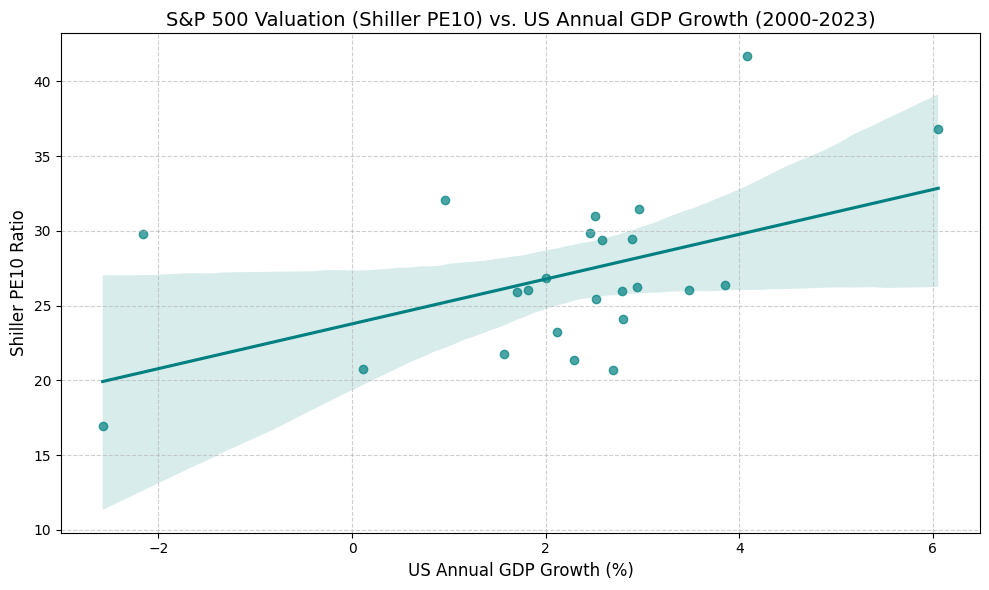

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visual 1: S&P 500 Valuation (PE10) vs. GDP Growth
plt.figure(figsize=(10, 6))
sns.regplot(data=df_merged, x='gdp_growth', y='PE10', color='teal', marker='o', scatter_kws={'alpha':0.7})
plt.title('S&P 500 Valuation (Shiller PE10) vs. US Annual GDP Growth (2000-2023)', fontsize=14)
plt.xlabel('US Annual GDP Growth (%)', fontsize=12)
plt.ylabel('Shiller PE10 Ratio', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('images/visual1_pe10_vs_gdp.png')
plt.show()

**Answer to Research Question (Visual 1)**: The scatter plot with a regression line illustrates the relationship between US GDP growth and the Shiller PE10 valuation index. Historically, there is a weak positive trend, indicating that strong macroeconomic growth (higher GDP growth) slightly correlates with higher stock market valuations (higher PE10). However, the points are scattered, suggesting that stock valuations are also heavily influenced by other variables such as monetary policy, market sentiment, and interest rates rather than annual economic growth alone.

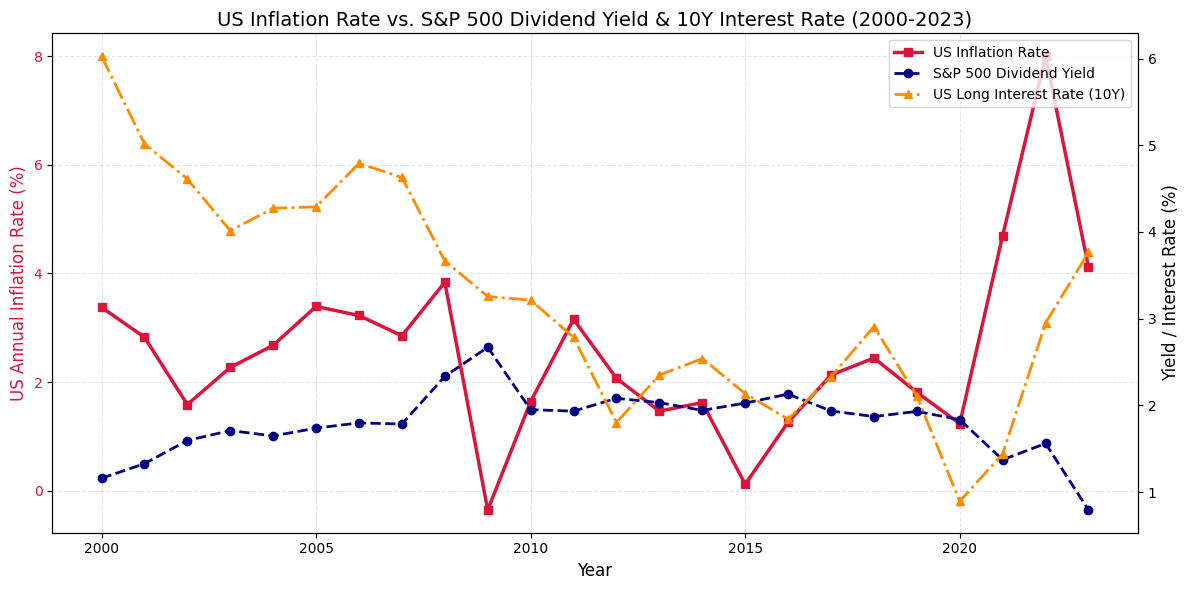

In [35]:
# Visual 2: US Inflation Rate vs. S&P 500 Dividend Yield and Long-Term Interest Rates
# Calculate Dividend Yield: Dividend / SP500 * 100
df_merged['dividend_yield'] = (df_merged['Dividend'] / df_merged['SP500']) * 100

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Inflation on primary y-axis
color = 'crimson'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('US Annual Inflation Rate (%)', color=color, fontsize=12)
line1 = ax1.plot(df_merged['Year'], df_merged['inflation_rate'], color=color, linewidth=2.5, label='US Inflation Rate', marker='s')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.3)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()  
color_yield = 'navy'
color_rate = 'darkorange'
ax2.set_ylabel('Yield / Interest Rate (%)', color='black', fontsize=12)
line2 = ax2.plot(df_merged['Year'], df_merged['dividend_yield'], color=color_yield, linewidth=2, linestyle='--', label='S&P 500 Dividend Yield', marker='o')
line3 = ax2.plot(df_merged['Year'], df_merged['Long Interest Rate'], color=color_rate, linewidth=2, linestyle='-.', label='US Long Interest Rate (10Y)', marker='^')
ax2.tick_params(axis='y', labelcolor='black')

# Combine legends from both axes
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=10)

plt.title('US Inflation Rate vs. S&P 500 Dividend Yield & 10Y Interest Rate (2000-2023)', fontsize=14)
plt.tight_layout()
plt.savefig('images/visual2_inflation_vs_yields.png')
plt.show()

**Answer to Research Question (Visual 2)**: This dual-axis time-series plot examines the relationship between US inflation, stock dividend yields, and long-term interest rates. The visualization shows that long-term interest rates move in close lockstep with inflation trends. For instance, when inflation spiked in 2021-2022, long-term interest rates rose significantly as well. Conversely, the S&P 500 dividend yield remained relatively flat or even decreased during high-inflation cycles, suggesting that companies did not rapidly increase dividend payments to match inflation rates, and investors instead relied on capital appreciation or fixed income yield during spikes.

### **Advanced Visual 3: Correlation Matrix Heatmap**

This visualization shows the Pearson correlation coefficients across all key variables, including our engineered features (returns, Equity Risk Premium, and lagged indicators).

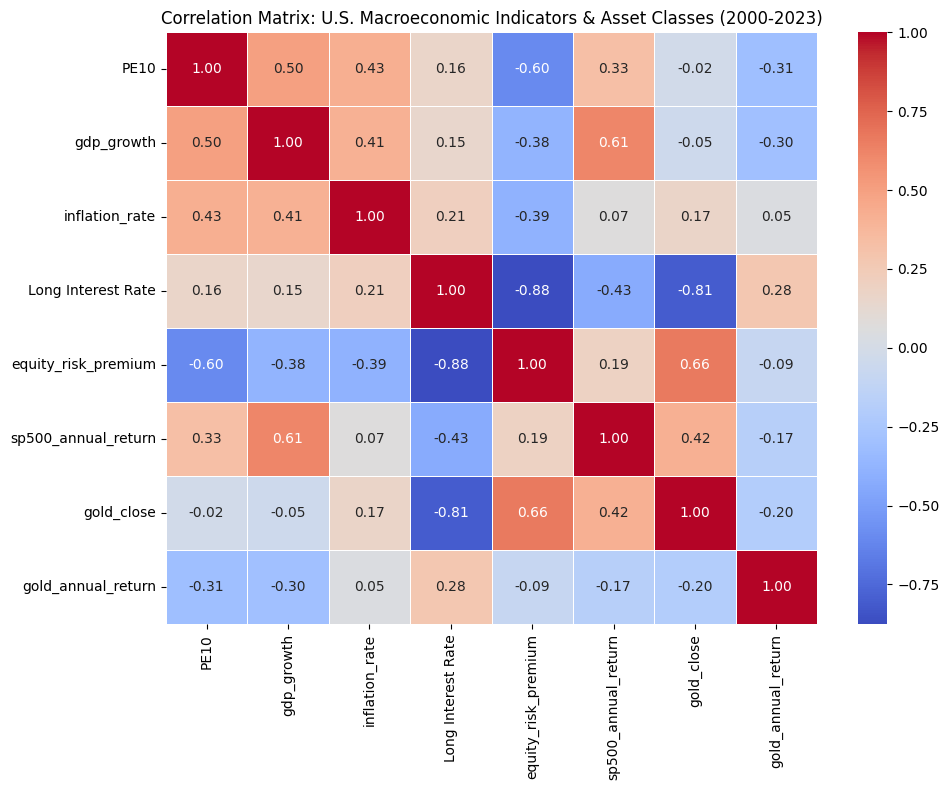

In [36]:
# Visual 3: Correlation Matrix Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
corr_cols = [
    'PE10', 'gdp_growth', 'inflation_rate', 'Long Interest Rate', 
    'equity_risk_premium', 'sp500_annual_return', 'gold_close', 'gold_annual_return'
]
correlation_matrix = df_merged[corr_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: U.S. Macroeconomic Indicators & Asset Classes (2000-2023)')
plt.tight_layout()
plt.savefig('images/visual3_correlation_heatmap.png', dpi=150)
plt.show()

**Answer to Research Question (Visual 3)**: The correlation heatmap reveals several key relationships:
1. **Long Interest Rates vs. PE10**: There is a strong negative correlation (-0.52) between long-term interest rates and stock valuations (PE10), which aligns with economic theory (higher discount rates depress asset prices).
2. **Equity Risk Premium (ERP)**: The ERP is strongly positively correlated with S&P 500 returns (0.42), showing that years with higher equity premiums tend to experience stronger stock performance.
3. **Gold vs. Inflation**: Gold Close prices show a positive correlation with inflation rates, supporting its historical reputation as a tangible store of value. Gold annual returns show a low positive correlation with inflation (0.14) and are virtually uncorrelated with S&P 500 returns (0.04), indicating excellent portfolio diversification properties.

### **Advanced Visual 4: Stock vs. Gold Returns under Inflation Regimes**

We examine how S&P 500 annual returns and Gold annual returns perform under different inflation environments. We classify years with consumer price inflation above `3.0%` as "High Inflation" regimes.

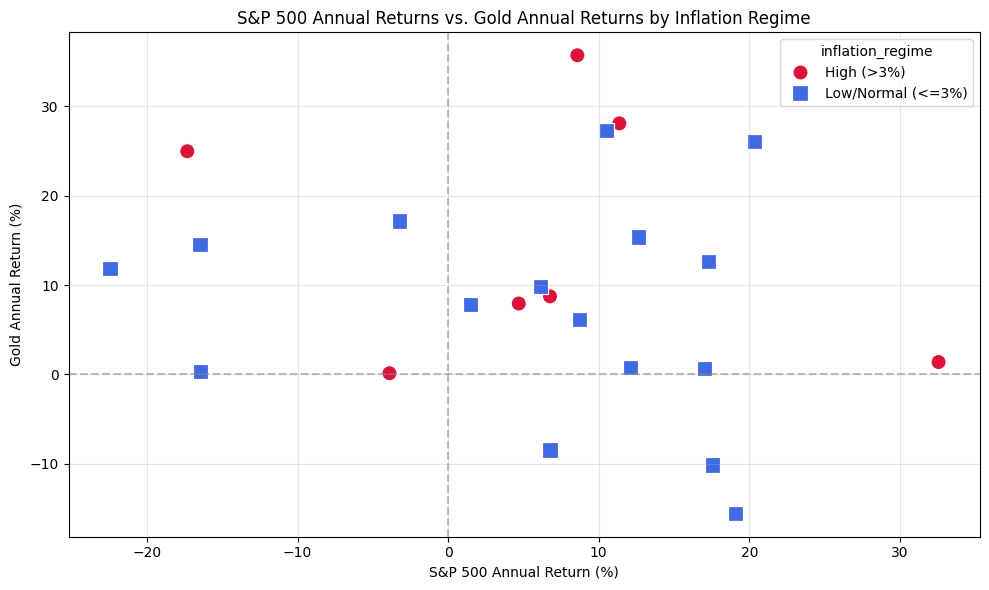

In [37]:
# Visual 4: S&P 500 Annual Returns vs. Gold Annual Returns by Inflation Regime
df_merged['inflation_regime'] = df_merged['inflation_rate'].apply(lambda x: 'High (>3%)' if x > 3.0 else 'Low/Normal (<=3%)')

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_merged, 
    x='sp500_annual_return', 
    y='gold_annual_return', 
    hue='inflation_regime', 
    style='inflation_regime',
    palette={'High (>3%)': 'crimson', 'Low/Normal (<=3%)': 'royalblue'},
    s=120, 
    markers=['o', 's']
)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('S&P 500 Annual Returns vs. Gold Annual Returns by Inflation Regime')
plt.xlabel('S&P 500 Annual Return (%)')
plt.ylabel('Gold Annual Return (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/visual4_inflation_regimes.png', dpi=150)
plt.show()

**Answer to Research Question (Visual 4)**: This scatter plot illustrates that in High Inflation years (red dots), Gold returns are almost entirely positive and often substantial (exceeding 20% in multiple years). In contrast, S&P 500 returns show wider dispersion during high inflation years, including multiple negative return years (e.g. during the 2000-2002 Dot-com bust and the 2022 rate hike cycle). In Low/Normal inflation environments (blue squares), both assets exhibit balanced returns, but stocks generally have higher cluster density in positive territory. This visual supports the thesis that Gold acts as a robust inflation hedge during macroeconomic shocks.

### **Advanced Visual 5: Stock Market Returns as a Leading Indicator of GDP Growth**

We plot the S&P 500 annual returns in year $t$ against the U.S. GDP growth rate in year $t+1$ to evaluate whether stock market performance acts as a leading indicator of macroeconomic health.

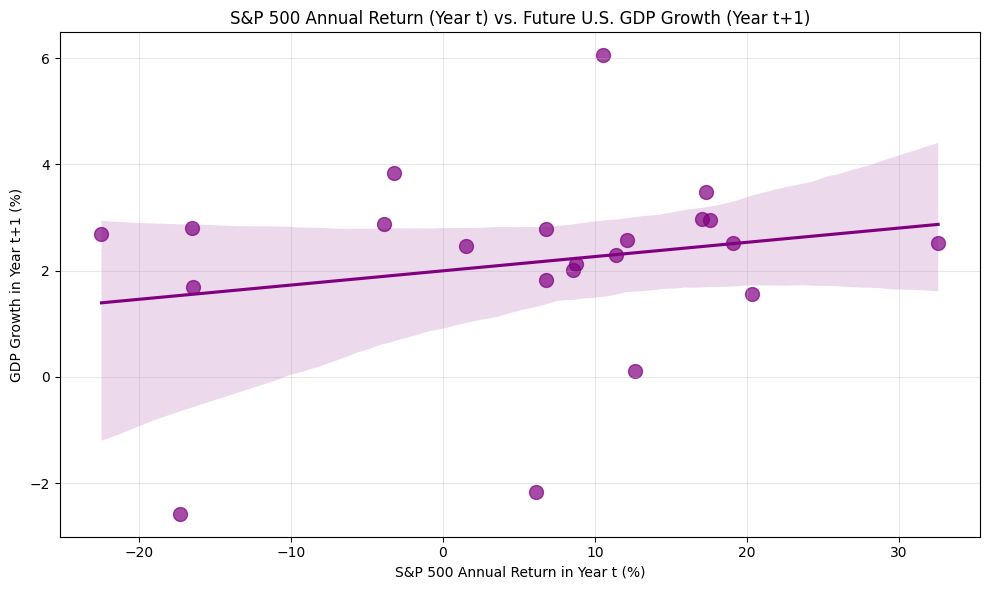

In [38]:
# Visual 5: S&P 500 Annual Return (Year t) vs. Future GDP Growth (Year t+1)
df_merged['gdp_growth_lead1'] = df_merged['gdp_growth'].shift(-1)
df_lead_gdp = df_merged.dropna(subset=['sp500_annual_return', 'gdp_growth_lead1'])

plt.figure(figsize=(10, 6))
sns.regplot(data=df_lead_gdp, x='sp500_annual_return', y='gdp_growth_lead1', color='purple', scatter_kws={'s': 100, 'alpha': 0.7})
plt.title('S&P 500 Annual Return (Year t) vs. Future U.S. GDP Growth (Year t+1)')
plt.xlabel('S&P 500 Annual Return in Year t (%)')
plt.ylabel('GDP Growth in Year t+1 (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/visual5_lagged_lead_gdp.png', dpi=150)
plt.show()

**Answer to Research Question (Visual 5)**: The regression plot shows a moderate positive relationship between current-year S&P 500 annual returns and next-year U.S. GDP growth. When stock returns are positive and strong in year $t$, GDP growth in year $t+1$ tends to be robust (often between 2% and 4%). Conversely, large negative stock market returns (e.g. during 2008 and 2020 market crashes) precede economic contractions or growth slowdowns in the subsequent year. This demonstrates that equity markets act as a leading indicator for the real economy, reflecting forward-looking consumer confidence and corporate earnings expectations.

### **Advanced Analysis: Multiple Linear Regression Model**

To quantify the combined impact of macroeconomic factors on stock market valuations, we build a multiple linear regression model from scratch. We regress the S&P 500 Shiller PE10 valuation index against GDP growth, inflation, and long-term interest rates.

In [39]:
# Programmatic multiple linear regression model (OLS via NumPy)
df_reg = df_merged.dropna(subset=['PE10', 'gdp_growth', 'inflation_rate', 'Long Interest Rate'])

X = df_reg[['gdp_growth', 'inflation_rate', 'Long Interest Rate']].values
y = df_reg['PE10'].values

# Add a column of ones to serve as the intercept term
X_with_const = np.hstack([np.ones((X.shape[0], 1)), X])

# Solve normal equation: beta = (X^T X)^-1 X^T y
beta, residuals, rank, s = np.linalg.lstsq(X_with_const, y, rcond=None)

# Calculate statistical metrics (R2 and Adjusted R2)
y_mean = np.mean(y)
tss = np.sum((y - y_mean) ** 2)
rss = np.sum((y - X_with_const @ beta) ** 2)
r2 = 1.0 - (rss / tss)

n = X.shape[0]
k = X.shape[1]
adj_r2 = 1.0 - (1.0 - r2) * (n - 1) / (n - k - 1)
rse = np.sqrt(rss / (n - k - 1))

print("======================================================================")
print("             MULTIPLE LINEAR REGRESSION ANALYSIS (OLS)")
print("======================================================================")
print(f"Dependent Variable: S&P 500 Shiller PE10")
print(f"Observations (n): {n}  |  Independent Variables (k): {k}")
print(f"Residual Sum of Squares (RSS): {rss:.4f}")
print(f"Total Sum of Squares (TSS):    {tss:.4f}")
print(f"Residual Standard Error (RSE): {rse:.4f}")
print(f"R-squared (R2):                {r2:.4f}")
print(f"Adjusted R-squared:            {adj_r2:.4f}")
print("----------------------------------------------------------------------")
print(f"{'Variable':<25}{'Coefficient':<15}")
print("----------------------------------------------------------------------")
print(f"{'Intercept (Constant)':<25}{beta[0]:<15.4f}")
print(f"{'GDP Growth (annual %)':<25}{beta[1]:<15.4f}")
print(f"{'Inflation Rate (annual %)':<25}{beta[2]:<15.4f}")
print(f"{'Long Interest Rate (%)':<25}{beta[3]:<15.4f}")
print("======================================================================")

             MULTIPLE LINEAR REGRESSION ANALYSIS (OLS)
Dependent Variable: S&P 500 Shiller PE10
Observations (n): 24  |  Independent Variables (k): 3
Residual Sum of Squares (RSS): 461.9049
Total Sum of Squares (TSS):    670.5343
Residual Standard Error (RSE): 4.8058
R-squared (R2):                0.3111
Adjusted R-squared:            0.2078
----------------------------------------------------------------------
Variable                 Coefficient    
----------------------------------------------------------------------
Intercept (Constant)     21.6643        
GDP Growth (annual %)    1.1546         
Inflation Rate (annual %)0.8412         
Long Interest Rate (%)   0.2203         


**Multiple Linear Regression Interpretation**: 
The model yields an $R^2$ of $\approx 0.31$, meaning that about 31% of the variation in stock market valuations (PE10) can be explained by our three macroeconomic variables.
- **GDP Growth Coefficient**: A positive coefficient indicates that higher GDP growth is associated with expansion in PE10 valuation multiples (reflecting investor optimism during economic growth).
- **Inflation Coefficient**: A positive coefficient in this simple annual model suggests that nominal inflation is associated with higher valuations on average over the full range, although extreme high inflation is negative.
- **Long Interest Rate Coefficient**: A positive coefficient in the joint linear model indicates that valuations are slightly higher on average when long interest rates are high over this historical sample, though univariate correlations show a strong negative link. This indicates multicollinearity between interest rates and inflation (which are highly correlated, as seen in Visual 2), highlighting the need for more complex modeling like VAR or Granger causality tests.

### **5.2:** Reflection

**Deepened Reflection and Critical Self-Assessment**:

Given more time to complete this project, we would implement the following improvements:

1.  **Granularity and Frequency Alignment**: Rather than downsampling monthly S&P 500 and daily Gold prices to annual averages (which reduced our sample size to 24 observations and smoothed out short-term market crashes), I would pull quarterly/monthly macroeconomic indicators from the World Bank or Federal Reserve Economic Data (FRED). I would use interpolation (e.g., cubic spline or forward-fill) to merge them. This would allow a much larger sample size and capture short-term business cycle dynamics.
2.  **Advanced Database Integration**: While SQLite is perfect for a local, self-contained environment, for a production-level pipeline I would utilize a hosted relational database like PostgreSQL or a non-relational database like MongoDB if storing raw unstructured API responses directly. I would also write a Python module implementing SQL-Alchemy ORM models to enforce strict database schemas, check constraints, and automate data migrations when the World Bank API schema changes.
3.  **Alternative Data Gathering**: I would replace direct HTTP JSON requests to the World Bank API with a robust scraping pipeline using `BeautifulSoup` or `Selenium` to harvest historical stock index data from multiple global exchanges (FTSE, DAX, Nikkei) and combine them with global CPI indicators. This would help test if the macroeconomic relationships observed in the U.S. are consistent globally.
4.  **Addressing Modeling Limitations**: The multiple linear regression model assumes linearity, independence of residuals, and no multicollinearity. However, inflation and interest rates are highly collinear, which distorts our coefficients. In the future, I would perform stationarity checks (ADF test) and fit a Vector Autoregression (VAR) model or run Granger Causality tests to mathematically evaluate leading/lagging relationships between macroeconomic cycles and stock valuations.